### House Price Predicition 

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV, LassoCV
from xgboost import XGBRegressor

In [3]:
# Reading dataset
house_train_data = pd.read_csv("house_train.csv")
house_test_data = pd.read_csv("house_test.csv")

In [4]:
house_train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
house_test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [6]:
# making a copy of the dataset
train_data = house_train_data.copy()
train_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [7]:
test_data = house_test_data.copy()
test_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [8]:
train_data.shape

(1460, 81)

In [9]:
test_data.shape

(1459, 80)

In [10]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [11]:
test_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [13]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

<b>This is for train_data

In [14]:
# Removing 'Id' 
train_data = train_data.drop(['Id'], axis = 1)

In [15]:
# Checking for null values
train_data.isna().sum().sort_values(ascending=False).head(30)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtExposure      38
BsmtFinType2      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
MasVnrType         8
Electrical         1
MSSubClass         0
Fireplaces         0
Functional         0
KitchenQual        0
KitchenAbvGr       0
BedroomAbvGr       0
HalfBath           0
FullBath           0
BsmtHalfBath       0
TotRmsAbvGrd       0
GarageCars         0
dtype: int64

In [16]:
missing_percent_train = (train_data.isna().sum() / len(train_data)) * 100
missing_percent_train.sort_values(ascending=False).head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
MasVnrType       0.547945
Electrical       0.068493
MSSubClass       0.000000
dtype: float64

In [17]:
# Dropping columns with high missing values 
miss_percent_train = (train_data.isna().sum() / len(train_data)) * 100 
high_missing = miss_percent_train[miss_percent_train > 80].index
train_data = train_data.drop(high_missing, axis = 1)

In [18]:
missing_percent_train = (train_data.isna().sum() / len(train_data)) * 100
missing_percent_train.sort_values(ascending=False).head(20)

FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrType       0.547945
MasVnrArea       0.547945
Electrical       0.068493
Fireplaces       0.000000
KitchenQual      0.000000
KitchenAbvGr     0.000000
BedroomAbvGr     0.000000
HalfBath         0.000000
dtype: float64

In [19]:
# Handling missing values (filling these with None)
nun_col = ['FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond',
        'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2', 'MasVnrType']

for col in nun_col:
    train_data[col] = train_data[col].fillna("None")

In [20]:
# Handling missing values (filling with zeroes)
zero_col = ['GarageYrBlt', 'GarageCars', 'GarageArea',
        'BsmtFullBath', 'BsmtHalfBath','BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
        'MasVnrArea']

for col in zero_col:
    train_data[col] = train_data[col].fillna(0)

In [21]:
# Handling missing values of LotFrontage. Handling it with median as per neighborhood
train_data['LotFrontage'] = train_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [22]:
# Handling missing values of categorical featuren (filling with mode values)
mode_col = ['MSZoning', 'Electrical', 'KitchenQual',
        'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional']

for col in mode_col:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])

In [23]:
# Droping 'Utilities' column because it has very low variance, it's has almost the same value
train_data = train_data.drop(['Utilities'], axis=1)

In [24]:
train_data.isna().sum().sort_values(ascending=False).head(40)

MSSubClass       0
GarageYrBlt      0
FireplaceQu      0
Fireplaces       0
Functional       0
TotRmsAbvGrd     0
KitchenQual      0
KitchenAbvGr     0
BedroomAbvGr     0
HalfBath         0
FullBath         0
BsmtHalfBath     0
BsmtFullBath     0
GrLivArea        0
LowQualFinSF     0
2ndFlrSF         0
1stFlrSF         0
GarageType       0
GarageFinish     0
CentralAir       0
GarageCars       0
SaleCondition    0
SaleType         0
YrSold           0
MoSold           0
MiscVal          0
PoolArea         0
ScreenPorch      0
3SsnPorch        0
EnclosedPorch    0
OpenPorchSF      0
WoodDeckSF       0
PavedDrive       0
GarageCond       0
GarageQual       0
GarageArea       0
Electrical       0
HeatingQC        0
MSZoning         0
RoofStyle        0
dtype: int64

In [25]:
# checking and handling duplicate values 
duplicate = train_data[train_data.duplicated()]
duplicate

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


<b> This is for test_data

In [26]:
# Removing 'Id' 
test_data = test_data.drop(['Id'], axis = 1)

In [27]:
# Checking for null values
test_data.isna().sum().sort_values(ascending=False).head(40)

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
FireplaceQu      730
LotFrontage      227
GarageYrBlt       78
GarageFinish      78
GarageQual        78
GarageCond        78
GarageType        76
BsmtCond          45
BsmtExposure      44
BsmtQual          44
BsmtFinType2      42
BsmtFinType1      42
MasVnrType        16
MasVnrArea        15
MSZoning           4
Functional         2
BsmtHalfBath       2
BsmtFullBath       2
Utilities          2
KitchenQual        1
SaleType           1
BsmtFinSF1         1
GarageCars         1
BsmtUnfSF          1
TotalBsmtSF        1
Exterior2nd        1
Exterior1st        1
GarageArea         1
BsmtFinSF2         1
TotRmsAbvGrd       0
KitchenAbvGr       0
Fireplaces         0
MSSubClass         0
HalfBath           0
PavedDrive         0
WoodDeckSF         0
dtype: int64

In [28]:
missing_percent_test = (test_data.isna().sum() / len(test_data)) * 100
missing_percent_test.sort_values(ascending=False).head(40)

PoolQC          99.794380
MiscFeature     96.504455
Alley           92.666210
Fence           80.123372
FireplaceQu     50.034270
LotFrontage     15.558602
GarageYrBlt      5.346127
GarageFinish     5.346127
GarageQual       5.346127
GarageCond       5.346127
GarageType       5.209047
BsmtCond         3.084304
BsmtExposure     3.015764
BsmtQual         3.015764
BsmtFinType2     2.878684
BsmtFinType1     2.878684
MasVnrType       1.096642
MasVnrArea       1.028101
MSZoning         0.274160
Functional       0.137080
BsmtHalfBath     0.137080
BsmtFullBath     0.137080
Utilities        0.137080
KitchenQual      0.068540
SaleType         0.068540
BsmtFinSF1       0.068540
GarageCars       0.068540
BsmtUnfSF        0.068540
TotalBsmtSF      0.068540
Exterior2nd      0.068540
Exterior1st      0.068540
GarageArea       0.068540
BsmtFinSF2       0.068540
TotRmsAbvGrd     0.000000
KitchenAbvGr     0.000000
Fireplaces       0.000000
MSSubClass       0.000000
HalfBath         0.000000
PavedDrive  

In [29]:
# Dropping columns of high missing values 
high_missing_cols = ['PoolQC','MiscFeature','Alley','Fence']

test_data = test_data.drop(high_missing_cols, axis = 1)

In [30]:
# Handling missing values (filling these with None)
nun_col = ['FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond',
        'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2', 'MasVnrType']

for col in nun_col:
    test_data[col] = test_data[col].fillna("None")

In [31]:
# Handling missing values (filling with zeroes)
zero_col = ['GarageYrBlt', 'GarageCars', 'GarageArea',
        'BsmtFullBath', 'BsmtHalfBath',
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
        'MasVnrArea']

for col in zero_col:
    test_data[col] = test_data[col].fillna(0)

In [32]:
# Handling missing values of LotFrontage. Handling it with median as per neighborhood
test_data['LotFrontage'] = test_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [33]:
# Handling missing values of categorical featuren (filling with mode values)
mode_col = ['MSZoning', 'Electrical', 'KitchenQual',
        'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional']

for col in mode_col:
    test_data[col] = test_data[col].fillna(test_data[col].mode()[0])

In [34]:
# Droping 'Utilities' column because it has very low variance, it's has almost the same value
test_data = test_data.drop(['Utilities'], axis=1)

In [35]:
test_data.isna().sum().sort_values(ascending=False).head(40)

MSSubClass       0
GarageType       0
Fireplaces       0
Functional       0
TotRmsAbvGrd     0
KitchenQual      0
KitchenAbvGr     0
BedroomAbvGr     0
HalfBath         0
FullBath         0
BsmtHalfBath     0
BsmtFullBath     0
GrLivArea        0
LowQualFinSF     0
2ndFlrSF         0
1stFlrSF         0
Electrical       0
FireplaceQu      0
GarageYrBlt      0
MSZoning         0
GarageFinish     0
SaleType         0
YrSold           0
MoSold           0
MiscVal          0
PoolArea         0
ScreenPorch      0
3SsnPorch        0
EnclosedPorch    0
OpenPorchSF      0
WoodDeckSF       0
PavedDrive       0
GarageCond       0
GarageQual       0
GarageArea       0
GarageCars       0
CentralAir       0
HeatingQC        0
Heating          0
TotalBsmtSF      0
dtype: int64

In [36]:
# checking and handling duplicate values 
duplicate2 = test_data[test_data.duplicated()]
duplicate2

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition


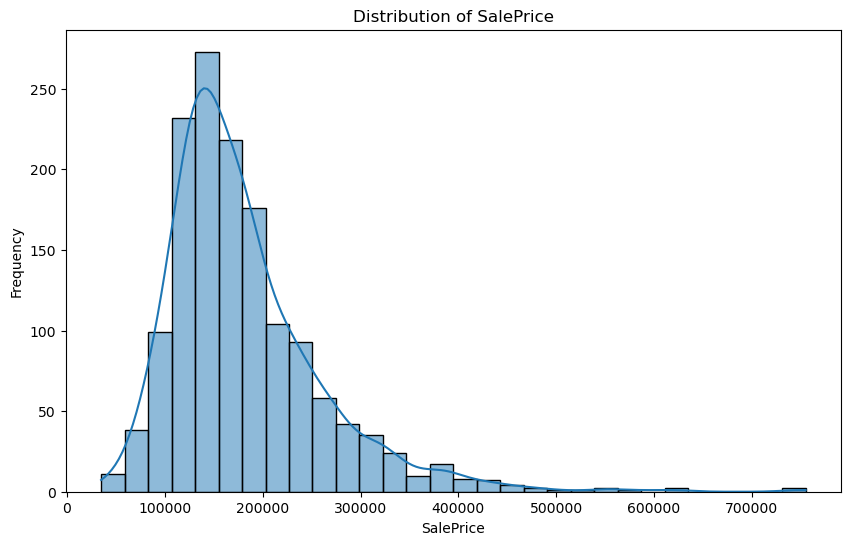

In [37]:
# EDA - SalePrice distribution, to check if its skewed
plt.figure(figsize = (10, 6))
sns.histplot(train_data['SalePrice'], kde = True, bins = 30)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

In [38]:
# Checking skewness
print(f"SalePrice Skewness: {train_data['SalePrice'].skew()}")

SalePrice Skewness: 1.8828757597682129


In [39]:
# Log transformation of SalePrice for linear based model
train_data['SalePrice_Log'] = np.log1p(train_data['SalePrice'])

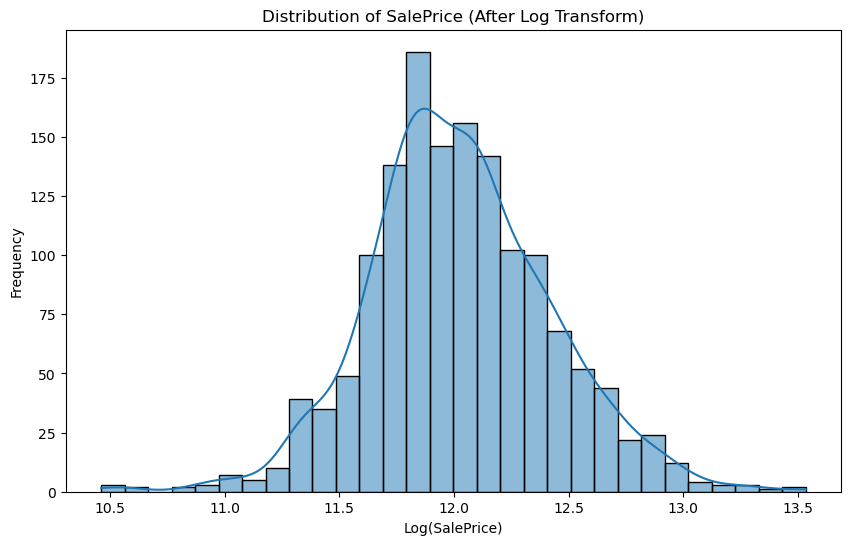

In [40]:
plt.figure(figsize=(10,6))
sns.histplot(train_data['SalePrice_Log'], kde=True, bins=30)
plt.title('Distribution of SalePrice (After Log Transform)')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frequency')
plt.show()

In [41]:
# Checking skewnskewness 
print("Log(SalePrice) Skewness:", train_data['SalePrice_Log'].skew())

Log(SalePrice) Skewness: 0.12134661989685333


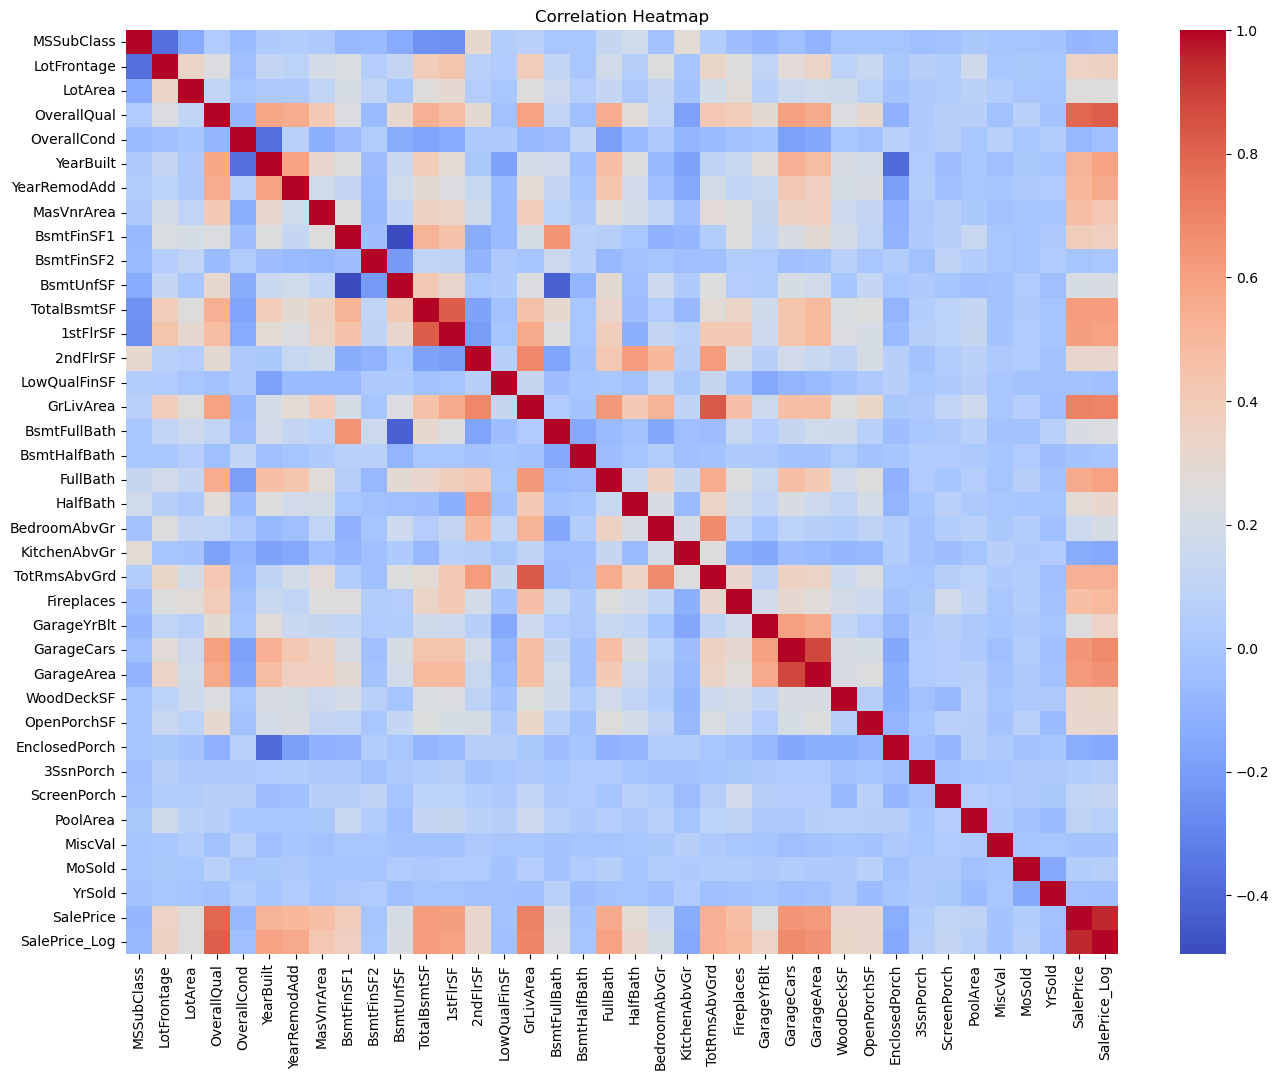

In [42]:
# Correlation for numerical features
numeric_cols = train_data.select_dtypes(include = ['int64', 'float64']).columns
corr_matrix = train_data[numeric_cols].corr()

plt.figure(figsize = (16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot = False)
plt.title('Correlation Heatmap')
plt.show()

In [43]:
corr_with_price = corr_matrix['SalePrice_Log'].sort_values(ascending=False).head(20)
corr_with_price

SalePrice_Log    1.000000
SalePrice        0.948374
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.426776
BsmtFinSF1       0.372023
LotFrontage      0.353288
GarageYrBlt      0.349013
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
Name: SalePrice_Log, dtype: float64

In [44]:
top_corr_feature = corr_with_price.drop(['SalePrice', 'SalePrice_Log']).head(5).index.tolist()
top_corr_feature

['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

In [45]:
# Categorical feature analysis
categorical_cols = train_data.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols.tolist())

Categorical Columns: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


C:\Users\Praveen Kumar\AppData\Local\Temp\ipykernel_18744\1702809006.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


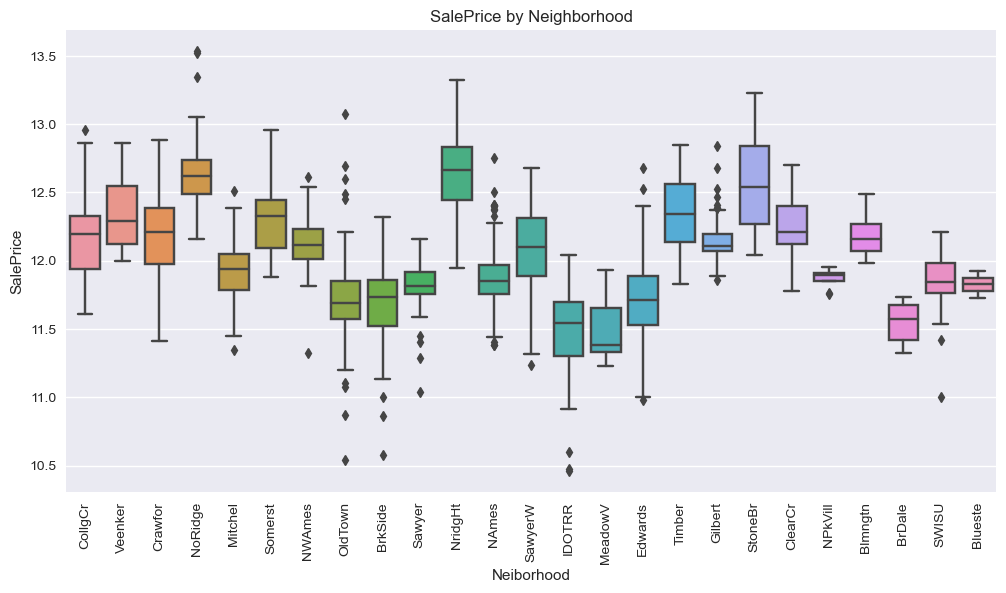

In [46]:
plt.style.use('seaborn')

# BoxPlot for neighborhood vs SalePrice_Log
plt.figure(figsize = (12 ,6))
sns.boxplot(x = 'Neighborhood', y = 'SalePrice_Log', data = train_data)
plt.title('SalePrice by Neighborhood')
plt.xlabel('Neiborhood')
plt.ylabel('SalePrice')
plt.xticks(rotation = 90)
plt.show()

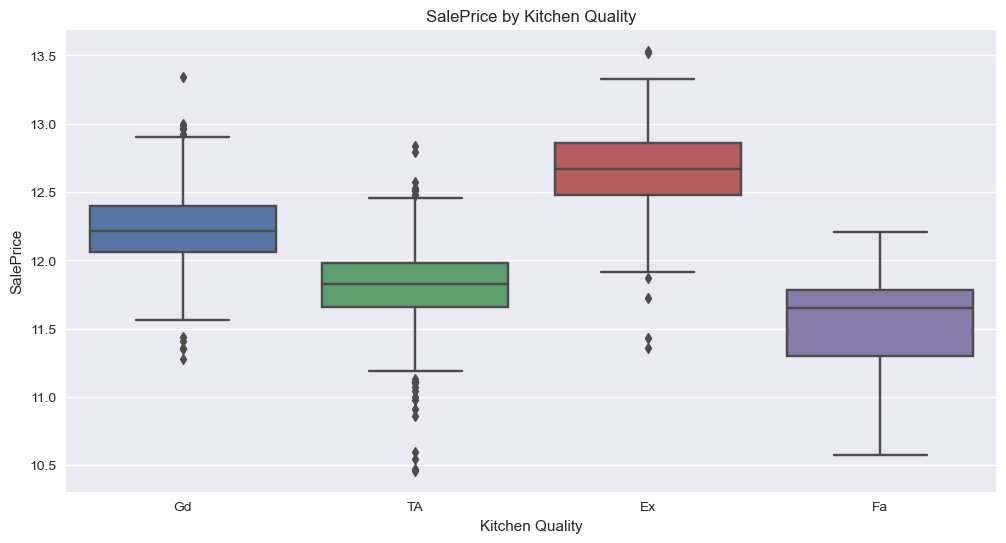

In [47]:
# BoxPlot for Kitchen Quality vs SalePrice_Log
plt.figure(figsize = (12 ,6))
sns.boxplot(x = 'KitchenQual', y = 'SalePrice_Log', data = train_data)
plt.title('SalePrice by Kitchen Quality')
plt.xlabel('Kitchen Quality')
plt.ylabel('SalePrice')
plt.show()

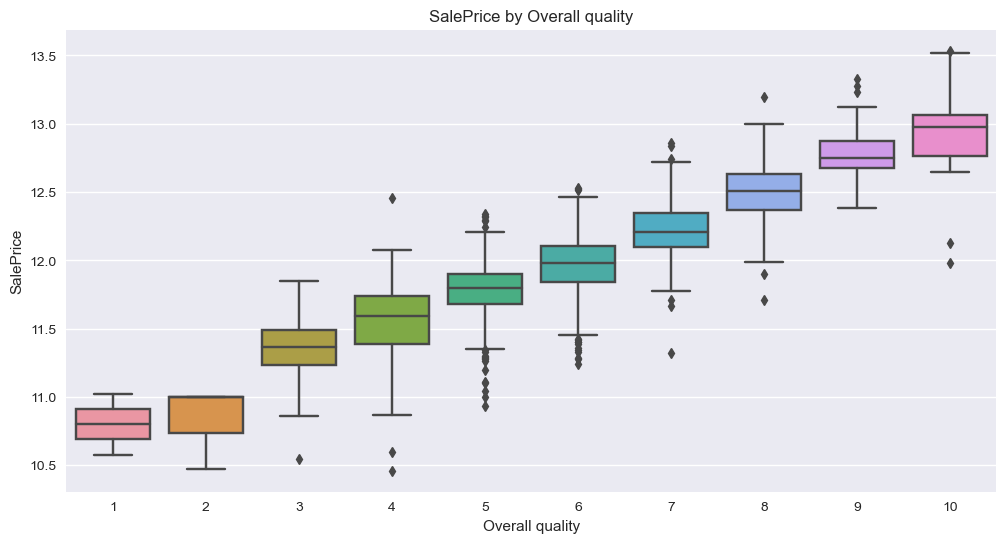

In [48]:
# BoxPlot for overall quality vs SalePrice_Log
plt.figure(figsize = (12 ,6))
sns.boxplot(x = 'OverallQual', y = 'SalePrice_Log', data = train_data)
plt.title('SalePrice by Overall quality')
plt.xlabel('Overall quality')
plt.ylabel('SalePrice')
plt.show()

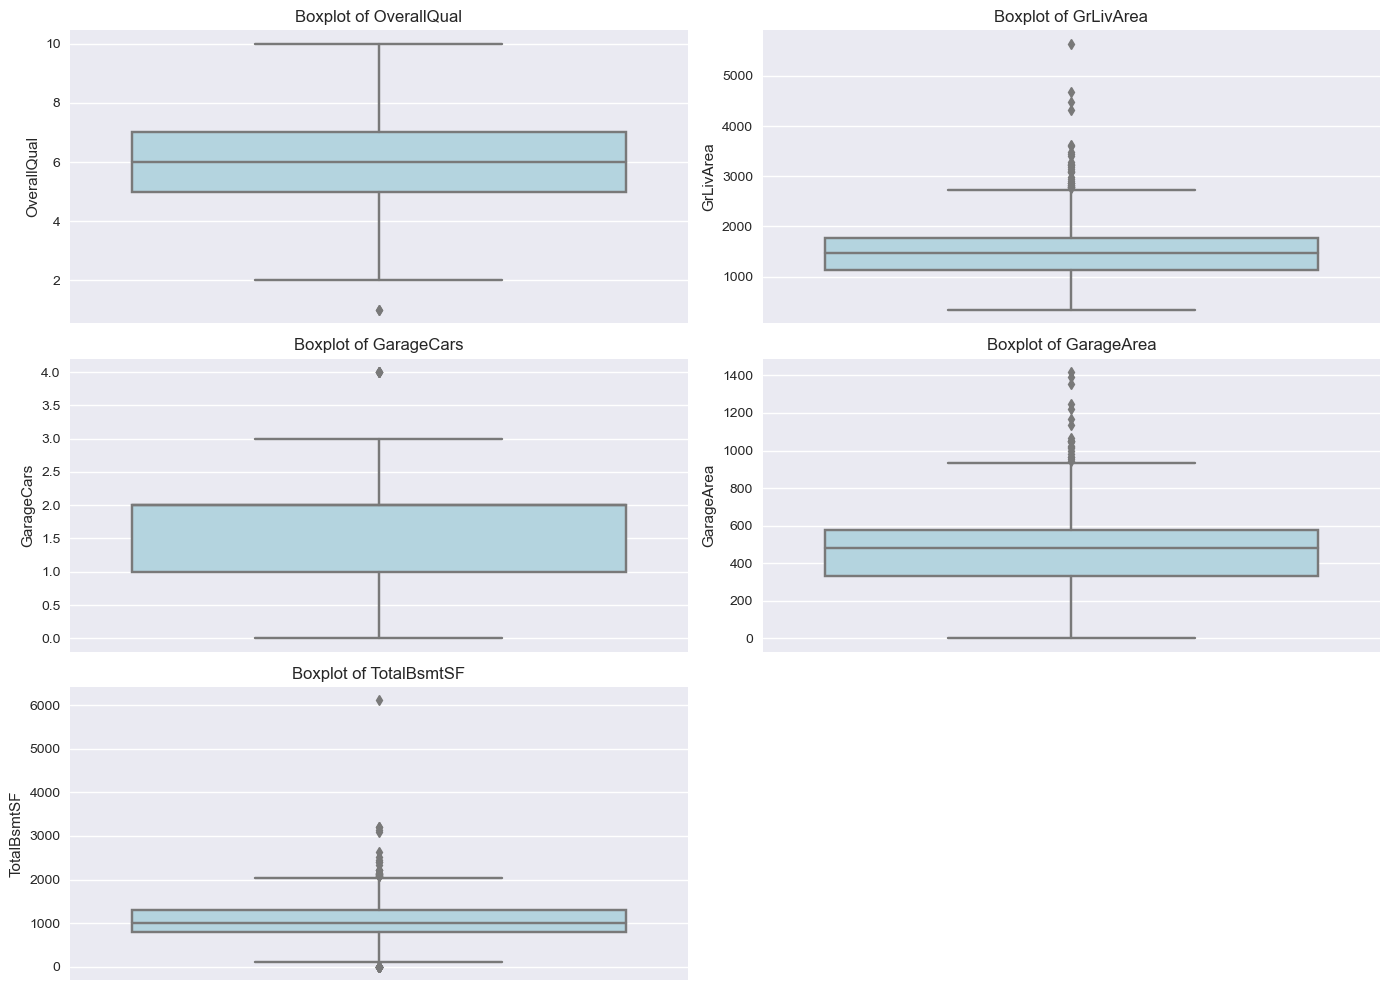

In [49]:
# Boxplot for outlier inspection 
plt.figure(figsize=(14,10))
for i, feature in enumerate(top_corr_feature):
    plt.subplot(3,2,i+1)
    sns.boxplot(data=train_data, y = feature, color = 'lightblue')
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

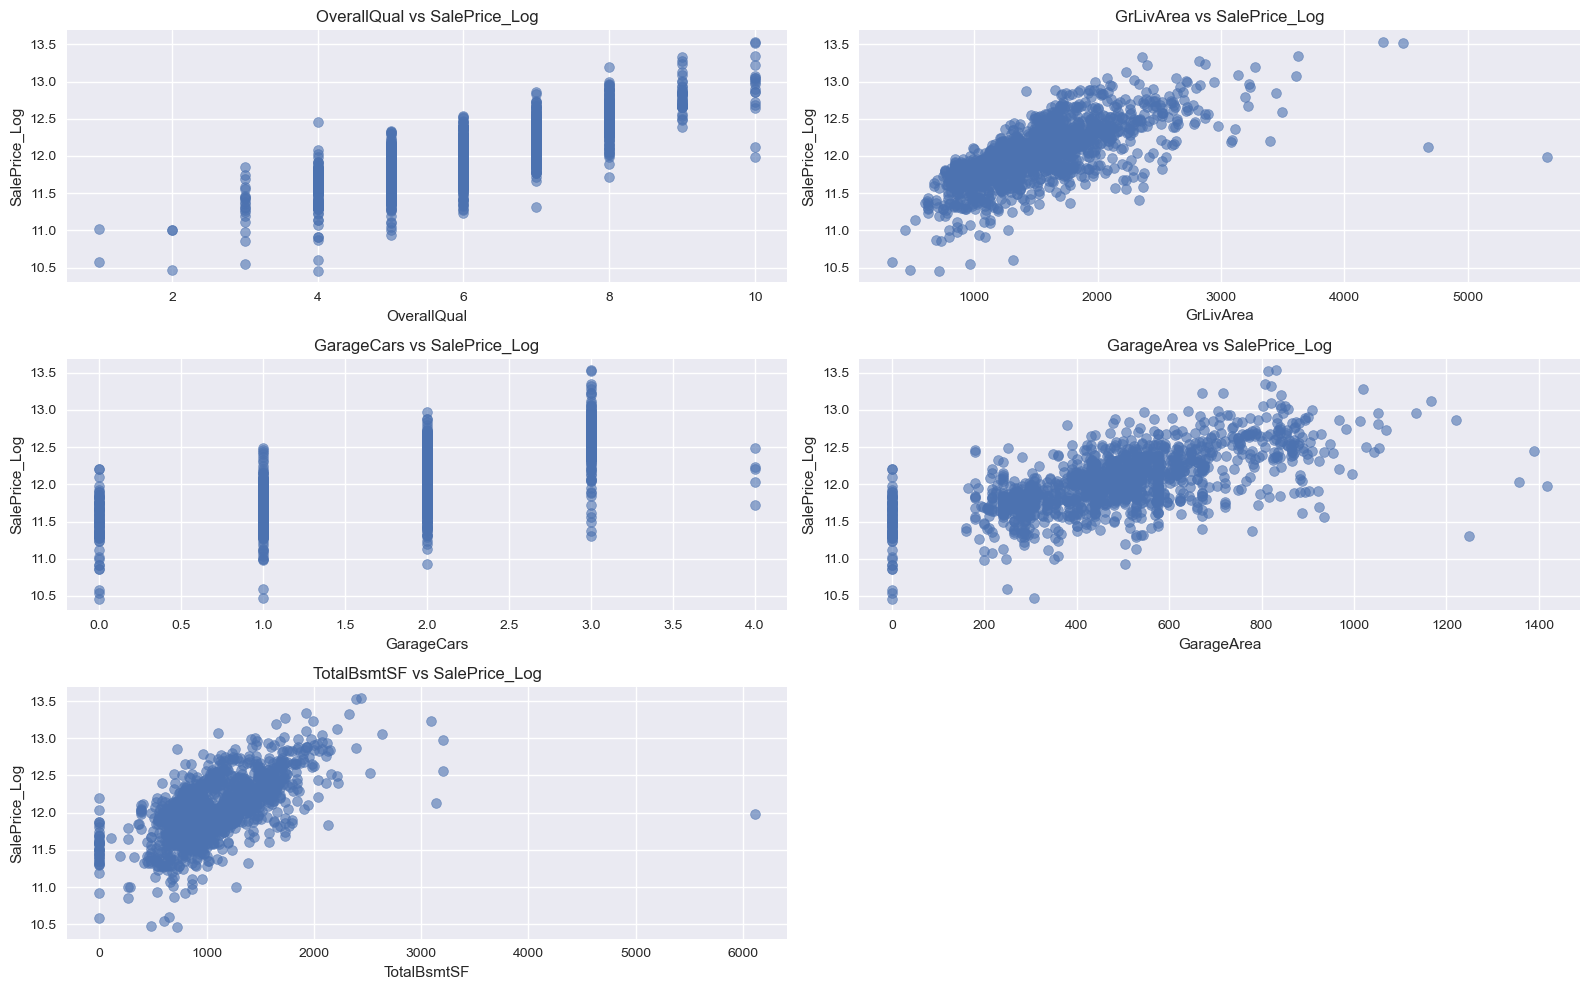

In [50]:
# Scatterplot to show outliers related to SalePrice_Log
plt.figure(figsize=(16,10))
for i, feature in enumerate(top_corr_feature):
    plt.subplot(3, 2, i+1)
    sns.scatterplot(data = train_data, x = feature, y = 'SalePrice_Log', alpha = 0.6, edgecolor = None)
    plt.title(f'{feature} vs SalePrice_Log')
plt.tight_layout()
plt.show()

C:\Users\Praveen Kumar\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


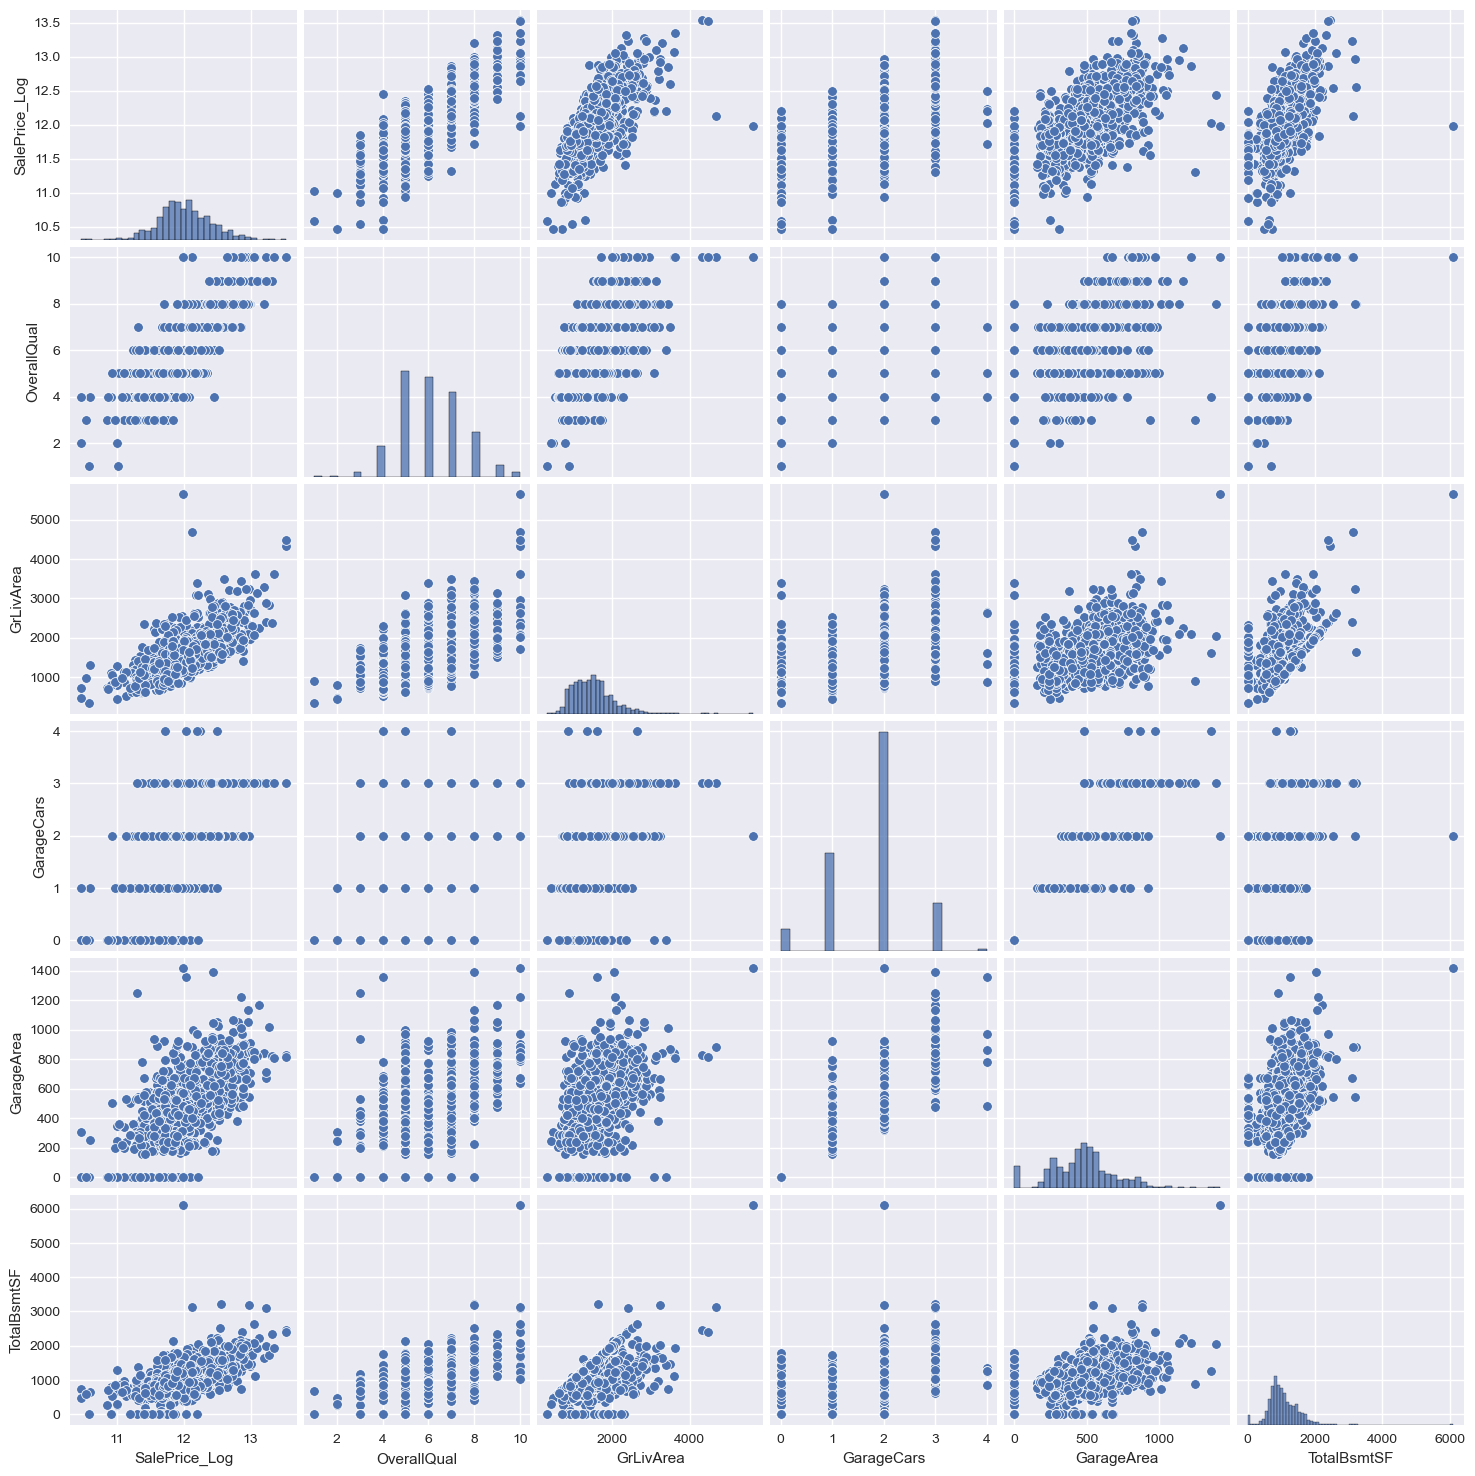

In [51]:
# Pair plot
# top_features = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageCars', 'OverallQual']
sns.pairplot(train_data[['SalePrice_Log'] + top_corr_feature])
plt.show()

In [52]:
# Numerical outlier detection usinf IQR
for feature in top_corr_feature:
    Q1 = train_data[feature].quantile(0.25)
    Q3 = train_data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 *IQR
    outliers = train_data[(train_data[feature] < lower_limit) | (train_data[feature] > upper_limit)]
    print(f" {feature}: {len(outliers)} outlier detected (Range: {lower_limit:.2f} to {upper_limit:.2f})")
    
    # capping outliers
    train_data[feature] = np.where(train_data[feature] < lower_limit, lower_limit,
                                  np.where(train_data[feature] > upper_limit, upper_limit, train_data[feature]))
    

 OverallQual: 2 outlier detected (Range: 2.00 to 10.00)
 GrLivArea: 31 outlier detected (Range: 158.62 to 2747.62)
 GarageCars: 5 outlier detected (Range: -0.50 to 3.50)
 GarageArea: 21 outlier detected (Range: -27.75 to 938.25)
 TotalBsmtSF: 61 outlier detected (Range: 42.00 to 2052.00)


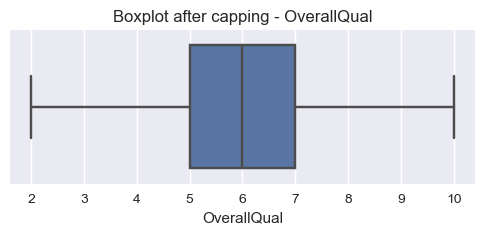

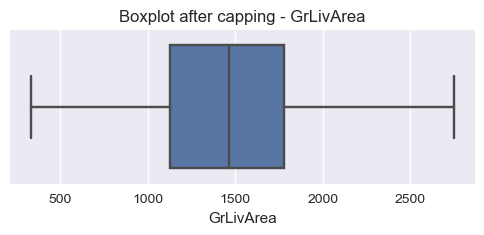

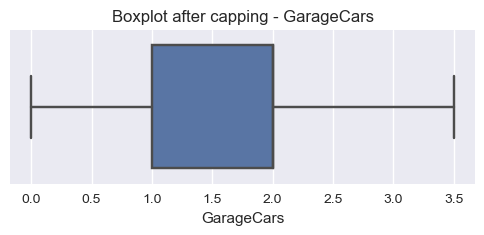

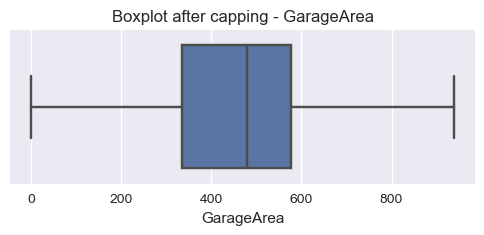

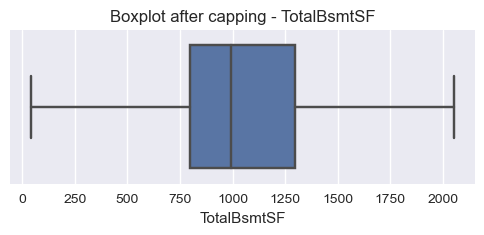

In [53]:
for feature in top_corr_feature:
    plt.figure(figsize = (6,2))
    sns.boxplot(x = train_data[feature])
    plt.title(f'Boxplot after capping - {feature}')
    plt.show()

In [54]:
# Applying this on test_data
for feature in top_corr_feature:
    Q1 = train_data[feature].quantile(0.25)
    Q3 = train_data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    test_data[feature] = np.where(test_data[feature] < lower_limit, lower_limit,
                          np.where(test_data[feature] > upper_limit, upper_limit, test_data[feature]))

In [55]:
# one-hot encoding train and test data
train_data_encoded = pd.get_dummies(train_data, drop_first = True)
test_data_encoded = pd.get_dummies(test_data, drop_first = True)

In [56]:
# Aligning both datasetes
train_data_encoded, test_data_encoded = train_data_encoded.align(test_data_encoded, join = 'left', axis = 1, fill_value = 0)

In [57]:
print("Train:", train_data_encoded.shape)
print("Test:", test_data_encoded.shape)

Train: (1460, 247)
Test: (1459, 247)


In [58]:
# dropping the target variable 
X = train_data_encoded.drop(columns = ['SalePrice_log'], errors = 'ignore')

# dropping dummy columns ending with '_None'
drop_none_cols = [col for col in X.columns if col.endswith('_None')]
if drop_none_cols:
    X = X.drop(columns = drop_none_cols)
    print(f"Dropped {len(drop_none_cols)} redundant '_None' columns")

# dropping constant columns 
constant_feature = [col for col in X.columns if X[col].nunique() == 1]
if constant_feature:
    X = X.drop(columns = constant_feature)
    print(f"Dropped {len(constant_feature)} constant columns")

# dropping highly correlated features
c_mat = X.corr().abs()
upper = c_mat.where(np.triu(np.ones(c_mat.shape), k = 1). astype(bool))
high_corr_features = [column for column in upper.columns if any(upper[column] > 0.95)]
if high_corr_features:
    X = X.drop(columns = high_corr_features)
    print(f"Dropped {len(high_corr_features)} highly correlated columns.")
    
# function to calculate clean high VIFs
def calculate_vif(df, thresh=10.0):
    print("\n Calculating VIF ...")
    vif_data = pd.DataFrame()
    vif_data['Feature'] = df.columns
    vif_data['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]

    # Identify problematic features
    high_vif_features = vif_data[vif_data['VIF'] > thresh]['Feature'].tolist()
    inf_vif_features = vif_data[vif_data['VIF'] == np.inf]['Feature'].tolist()

    if high_vif_features or inf_vif_features:
        to_drop = list(set(high_vif_features + inf_vif_features))
        print(f"Dropping {len(to_drop)} high-VIF features: {to_drop[:5]}{'...' if len(to_drop) > 5 else ''}")
        df = df.drop(columns=to_drop, errors='ignore')
        return df, True
    else:
        print("No high VIFs found")
        return df, False
    
# Running iterative VIF cleaning
iteration = 0
while True:
    iteration += 1
    print(f"\n Iteration {iteration}")
    X, has_high_vif = calculate_vif(X)
    if not has_high_vif:
        break

# Final VIF Summary
final_vif = pd.DataFrame()
final_vif['Feature'] = X.columns
final_vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n Final top features with highest VIF (after cleaning):")
display(final_vif.sort_values(by='VIF', ascending=False))


Dropped 11 redundant '_None' columns
Dropped 5 highly correlated columns.

 Iteration 1

 Calculating VIF ...
Dropping 84 high-VIF features: ['BsmtQual_Gd', 'PavedDrive_Y', 'Neighborhood_NAmes', 'BsmtUnfSF', 'KitchenAbvGr']...

 Iteration 2

 Calculating VIF ...
No high VIFs found

 Final top features with highest VIF (after cleaning):


,Feature,VIF
13,MoSold,6.425464
102,BsmtExposure_No,6.170879
23,LotConfig_Inside,5.189366
0,LotArea,5.004389
17,LotShape_Reg,3.935592
...,...,...
85,Exterior2nd_Other,1.080311
71,RoofMatl_Roll,1.079096
140,SaleType_ConLI,1.069147
137,SaleType_CWD,1.066405


In [59]:
# Defining target 
y = train_data_encoded['SalePrice_Log']

In [60]:
# splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

In [61]:
# standardizing features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
# training model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [63]:
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('R2: ', r2)
print('RMSE: ', rmse)

R2:  0.731384111390048
RMSE:  0.22388987588594583


In [64]:
# Ridge Regression (L2)
ridge = RidgeCV(alphas = np.logspace(-3, 3, 25), cv = 5)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print(f"[Ridge]  R2: {ridge_r2:.4f}, RMSE: {ridge_rmse:.4f}, Best alpha: {ridge.alpha_:.4f}")

[Ridge]  R2: 0.7267, RMSE: 0.2258, Best alpha: 316.2278


In [65]:
# Lasso Regression (L1)
lasso = LassoCV(alphas = np.logspace(-3, 1, 30), cv = 5, max_iter = 5000, n_jobs = -1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print(f"[Lasso]  R2: {lasso_r2:.4f}, RMSE: {lasso_rmse:.4f}, Best alpha: {lasso.alpha_:.4f}")

[Lasso]  R2: 0.7279, RMSE: 0.2254, Best alpha: 0.0067


In [66]:
# Refit scaler on full feature set
scaler_final = StandardScaler()
X_scaled_full = scaler_final.fit_transform(X)

# training Ridge on all data
ridge_final = RidgeCV(alphas=np.logspace(-3, 3, 25), cv=5)
ridge_final.fit(X_scaled_full, y)

# Scaling test data (align columns with X)
X_test_final_scaled = scaler_final.transform(test_data_encoded[X.columns])

# Predict (log scale)
y_test_pred_log = ridge_final.predict(X_test_final_scaled)

# Convert back to original price scale
y_test_pred = np.expm1(y_test_pred_log)

# Creating a DataFrame to view predictions directly in the notebook
submission = pd.DataFrame({
    "Id": house_test_data["Id"],
    "Predicted_SalePrice": y_test_pred
})

# Displaying the first few predictions
print("Final Ridge model trained. Here are the first predictions:")
display(submission.head(10))


Final Ridge model trained. Here are the first predictions:


,Id,Predicted_SalePrice
0,1461,113183.407605
1,1462,165310.906631
2,1463,192550.001701
3,1464,222554.781634
4,1465,193262.701166
5,1466,174983.500432
6,1467,166050.794554
7,1468,165108.293946
8,1469,177847.070205
9,1470,131374.718298


In [67]:
# saving submission file
submission = pd.DataFrame({
    "Id": house_test_data["Id"],
    "SalePrice": y_test_pred
})
submission.to_csv("submission_ridge.csv", index=False)

print("Final Ridge model trained and predictions saved as 'submission_ridge.csv'")

Final Ridge model trained and predictions saved as 'submission_ridge.csv'


In [68]:
# Converting log-scale values back to actual prices for business interpretation and tableau
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

In [69]:
# RSME for actual price scale
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("RMSE on Actual Price Scale:", rmse_actual)

RMSE on Actual Price Scale: 44534.234616216796


In [75]:
# Using XGBoost model
xgb_model = XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    reg_lambda = 1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [79]:
y_pred_xgb_log = xgb_model.predict(X_test)

# Converting back fron log scale 
y_pred_xgb = np.expm1(y_pred_xgb_log)
y_test_actual = np.expm1(y_test)

xgb_r2 = r2_score(y_test_actual, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb))

print("XGBoost R2:", xgb_r2)
print("XGBoost RMSE:", xgb_rmse)

XGBoost R2: 0.7743997381572979
XGBoost RMSE: 41598.408632546954


In [70]:
# Exporting tableau ready dataset
X_test_df = pd.DataFrame(X_test, columns = X.columns)
tableau_df = X_test_df.copy()
tableau_df['actual_price'] = y_test_actual
tableau_df['predicted_price'] = y_pred_actual
tableau_df['error'] = tableau_df['predicted_price'] - tableau_df['actual_price']

tableau_df.to_csv("house_price_tableau.csv", index = False)
print("house_price_tableau.csv exported successfully")

house_price_tableau.csv exported successfully


In [82]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "XGBoost"],
    "R2 Score": [r2, ridge_r2, lasso_r2, xgb_r2],
    "RMSE": [rmse, ridge_rmse, lasso_rmse, xgb_rmse]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.731384,0.223890
1,Ridge,0.726729,0.225822
2,Lasso,0.727855,0.225356
3,XGBoost,0.774400,41598.408633


In [84]:
# Final Training on FULL Dataset
xgb_final = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    reg_lambda=1
)

xgb_final.fit(X, y)

# Predict on Test Dataset
X_test_ext = test_data_encoded[X.columns]

y_test_pred_log = xgb_final.predict(X_test_ext)
y_test_pred = np.expm1(y_test_pred_log)

submission_xgb = pd.DataFrame({
    "Id": house_test_data["Id"],
    "SalePrice": y_test_pred
})

submission_xgb.to_csv("submission_xgboost.csv", index=False)

print("XGBoost submission saved!")

XGBoost submission saved!
